In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42) # for reproducibility


## Data preparation

In [59]:
spect = np.load('spectrums.npy')    # spectra, wavelengths, uncertainties - input data
label = pd.read_csv('FM_Parameter_Table.csv') # labels - data we want to predict
auxill = pd.read_csv('AuxillaryTable.csv') # additional input data we use

wavelengths = spect[ 0, :, 0]
spectrum = spect[:, :, 1]
unc = spect[:, :,2]

wavelengths.shape

(52,)

Let's see how the spectra normalized to their mean values look like

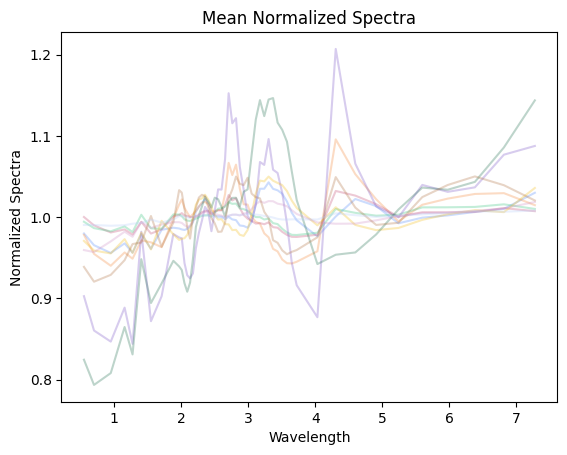

In [60]:
rand_ids = np.random.choice(len(spectrum), 10)
for i in rand_ids:
    plt.plot(wavelengths, spectrum[i]/np.mean(spectrum[i]), alpha=0.3)

plt.title('Mean Normalized Spectra')
plt.ylabel('Normalized Spectra')
plt.xlabel('Wavelength')
plt.show()


In [82]:
param_names = ['planet_radius', 'planet_temp', 'log_H2O','log_CO2', 'log_CO', 'log_CH4', 'log_NH3'] # We keep the labels for further plots
output = label[param_names].values

In [83]:
def our_min_max(data, axis=1):
    """
    Normalize data to [0,1], saving normalization coefficients
    """
    norm_k = (np.max(data, axis=axis) - np.min(data, axis=axis)).reshape(-1,1)
    res = (data - np.min(data, axis=axis).reshape(-1,1))/norm_k
    return res, norm_k

Data normalization

In [63]:
y_scaler = MinMaxScaler()
y_norm = y_scaler.fit_transform(output)

aux_norm = MinMaxScaler().fit_transform(auxill.drop('planet_ID', axis=1))
X_norm, norm_koeffs = our_min_max(spectrum)

input_data = np.concatenate((X_norm, aux_norm), axis=1) # we concatenate the normalized spectra and the normalized auxillary data
input_data.shape

(41423, 60)

Now let's see how our final version (min-max normalized) of input spectra looks like

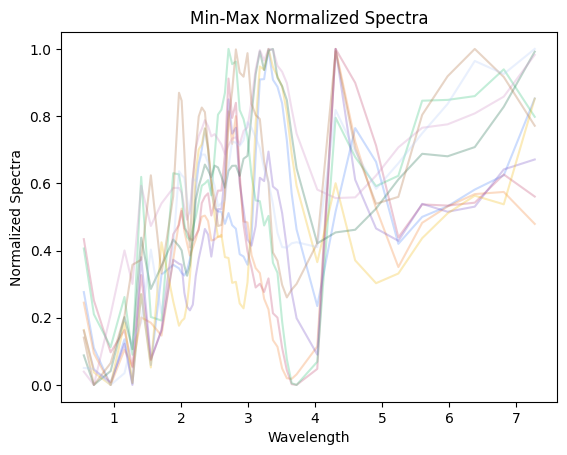

In [64]:
for i in rand_ids:
    plt.plot(wavelengths, X_norm[i], alpha=0.3)

plt.title('Min-Max Normalized Spectra')
plt.ylabel('Normalized Spectra')
plt.xlabel('Wavelength')
plt.show()


We keep 10% of the initial dataset as validation (test) data

In [70]:
X_train, X_test, y_train, y_test = train_test_split(input_data, y_norm, test_size=0.1, random_state=1)

input_data.shape[1]

60

## FNN setup and training

In [85]:
callback = keras.callbacks.EarlyStopping(monitor = 'loss', patience=3)
n = output.shape[1]
model = tf.keras.Sequential([tf.keras.Input(shape=(input_data.shape[1],)),
tf.keras.layers.Dense(200, activation='relu'),
tf.keras.layers.Dense(100, activation='relu'),
tf.keras.layers.Dense(50, activation='relu'),
tf.keras.layers.Dense(n)
])


model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 200)            │        12,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,707 (147.29 KB)

 Trainable params: 37,707 (147.29 KB)

 Non-trainable params: 0 (0.00 B)

We train our neural network and keep the trainig history

In [72]:
history = model.fit(X_train, y_train, validation_data = (X_test, y_test),
          epochs=100, shuffle=True, callbacks=[callback],
          batch_size=200)

Epoch 1/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0369 - mae: 0.1412 - val_loss: 0.0200 - val_mae: 0.1091
Epoch 2/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0162 - mae: 0.0938 - val_loss: 0.0142 - val_mae: 0.0872
Epoch 3/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0124 - mae: 0.0795 - val_loss: 0.0124 - val_mae: 0.0768
Epoch 4/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0103 - mae: 0.0709 - val_loss: 0.0103 - val_mae: 0.0681
Epoch 5/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0090 - mae: 0.0651 - val_loss: 0.0086 - val_mae: 0.0630
Epoch 6/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0082 - mae: 0.0617 - val_loss: 0.0095 - val_mae: 0.0687
Epoch 7/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0075 - mae: 0.0586 - val_loss: 0.0078 - val_mae: 0.0593
Epoch 8/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0069 - mae: 0.0557 - val_loss: 0.0078 - val_mae: 0.0601
Epoch 9/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/

We use mean squared error of the __normalized__ data as a measurement of FNN performance on our test data

In [74]:
y_pred = model.predict(X_test)
loss, accuracy  = model.evaluate(X_test, y_test)
quality = np.sum((y_pred-y_test)**2, axis=0)/y_test.shape[0]


130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0039 - mae: 0.0366


For illustration purposes we restore the original range of physical parameters

In [75]:
y_test_phys = y_scaler.inverse_transform(y_test)
y_pred_phys = y_scaler.inverse_transform(y_pred)

## Results

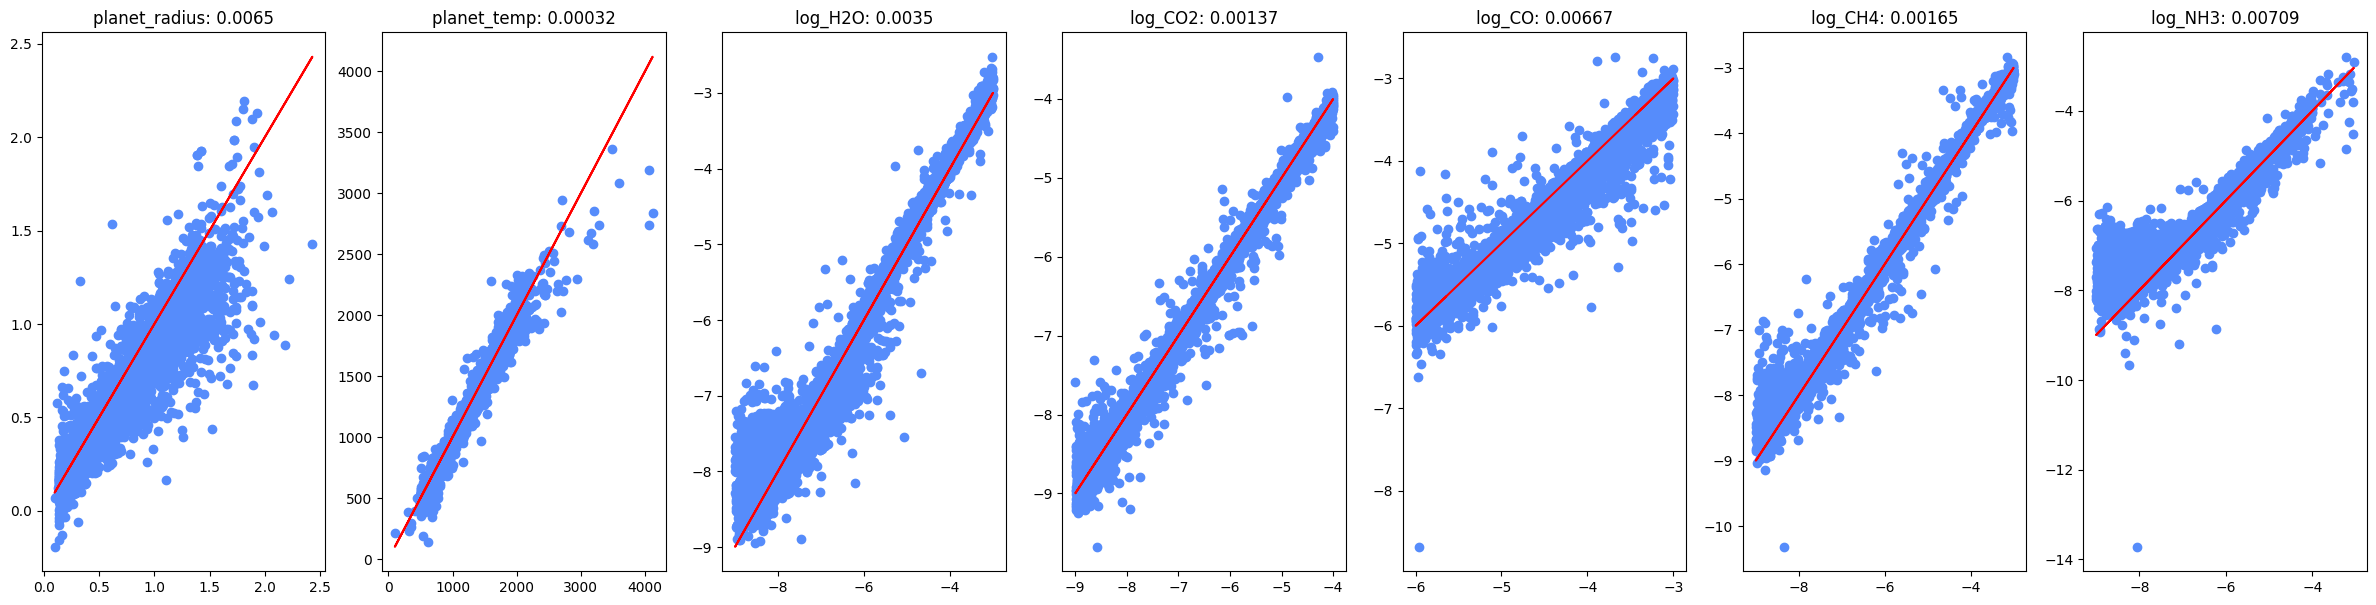

In [76]:
# 4 layers
fig, axes = plt.subplots(1, n, figsize=(30,7))
axes_flat = axes.flatten()
for i in range(n):
    axes_flat[i].set_title(f'{param_names[i]}: {np.round(quality[i], 5)}')
    axes_flat[i].scatter(y_test_phys[:,i], y_pred_phys[:,i])
    axes_flat[i].plot(y_test_phys[:,i], y_test_phys[:,i], 'r')

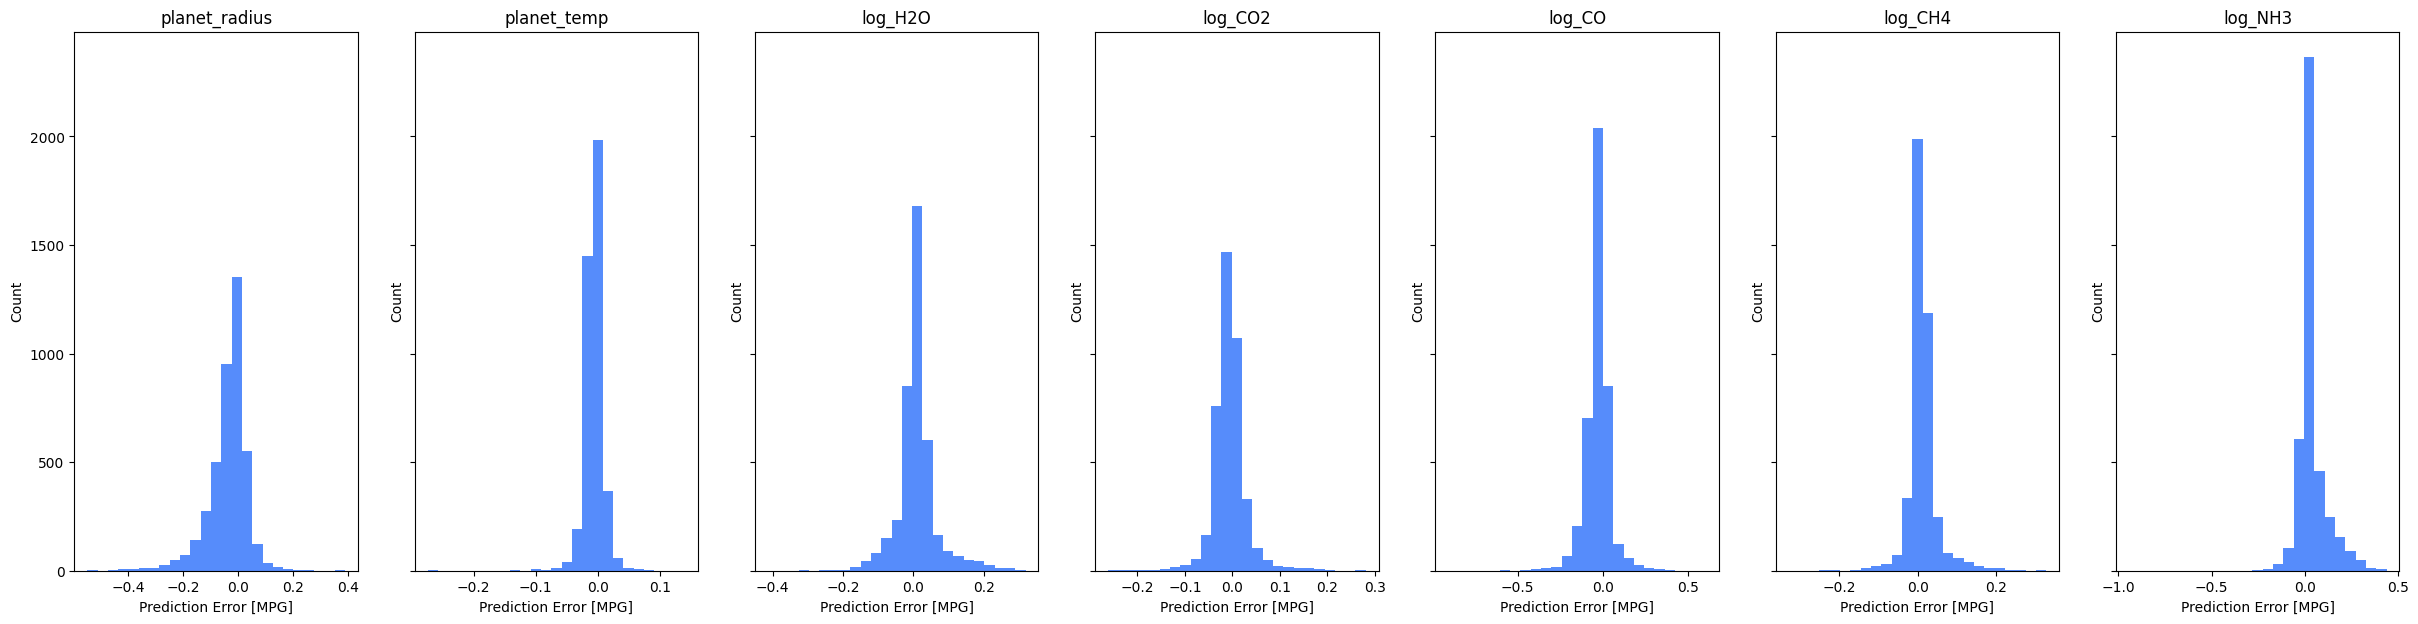

In [80]:
fig, ax = plt.subplots(1, n, figsize=(30,7), sharey=True)
for i in range(n):
  error = y_pred[:,i] - y_test[:,i]
  ax[i].hist(error, bins=25)
  ax[i].set_xlabel('Prediction Error [MPG]')
  ax[i].set_ylabel('Count')
  ax[i].set_title(f'{param_names[i]}')

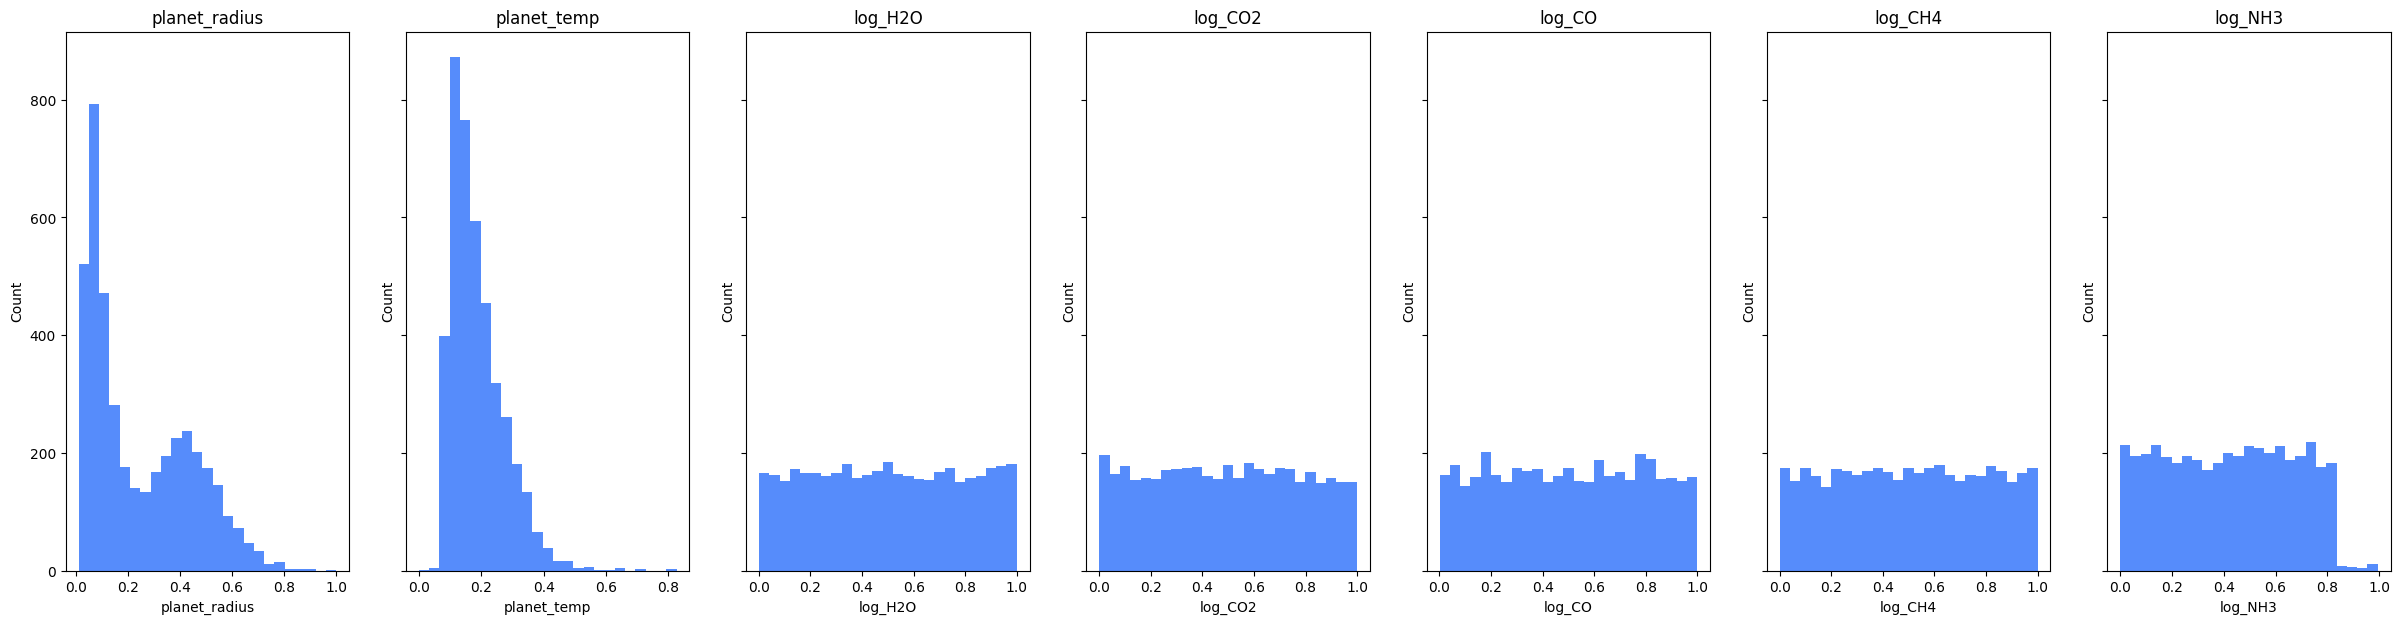

In [81]:
fig, ax = plt.subplots(1, n, figsize=(30,7), sharey=True)
for i, param in enumerate(param_names):
    ax[i].hist(y_test[:,i], bins=25)
    ax[i].set_xlabel(param)
    ax[i].set_ylabel('Count')
    ax[i].set_title(f'{param}')


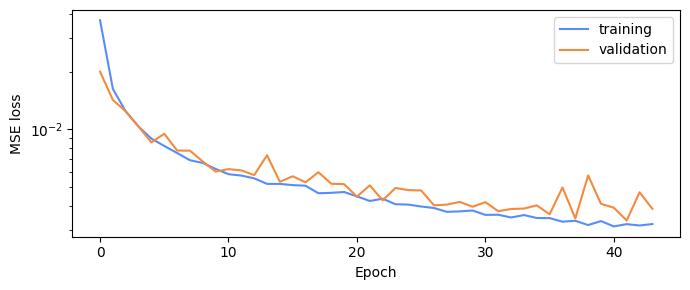

In [78]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(training_loss, label='training')
ax.plot(validation_loss, label='validation')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

## Bonus: visual comparision of spectra

In [86]:
label

,Unnamed: 0,planet_ID,planet_radius,planet_temp,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
0,0,train1,0.559620,863.394770,-8.865868,-6.700707,-5.557561,-8.957615,-3.097540
1,1,train2,1.118308,1201.700465,-4.510258,-8.228966,-3.565427,-7.807424,-3.633658
2,2,train3,0.400881,1556.096477,-7.225472,-6.931472,-3.081975,-8.567854,-5.378472
3,3,train4,0.345974,1268.624884,-7.461157,-5.853334,-3.044711,-5.149378,-3.815568
4,4,train5,0.733184,1707.323564,-4.140844,-7.460278,-3.181793,-5.996593,-4.535345
...,...,...,...,...,...,...,...,...,...
41418,41418,train41419,1.430950,1167.563319,-7.556565,-7.075889,-4.735715,-7.532563,-7.854443
41419,41419,train41420,0.277752,649.703932,-7.434332,-7.161510,-5.274940,-4.100312,-3.651804
41420,41420,train41421,0.136016,1445.371723,-5.525906,-5.079240,-4.945121,-5.787630,-8.015444
41421,41421,train41422,0.707851,653.284686,-4.616695,-8.782546,-3.767229,-3.221403,-8.427805


These planets were chosen manually using tools for working with pandas dataframe from the IDE

In [107]:
lowT_highCO2_ind = [39516, 38555, 38735, 38923]
lowT_lowCO2_ind = [38386, 39498, 38867, 38388]
highT_highCO2_ind = [36995, 38726, 32627, 7713]
highT_lowCO2_ind = [35904, 3132, 15920, 17464]

In [108]:
print('Low Temperature, High CO2:')
print(label.loc[lowT_highCO2_ind, ['planet_temp', 'log_CO2']])
print()
print('Low Temperature, Low CO2:')
print(label.loc[lowT_lowCO2_ind, ['planet_temp', 'log_CO2']])
print()
print('High Temperature, High CO2:')
print(label.loc[highT_highCO2_ind, ['planet_temp', 'log_CO2']])
print()
print('High Temperature, Low CO2:')
print(label.loc[highT_lowCO2_ind, ['planet_temp', 'log_CO2']])

Low Temperature, High CO2:
       planet_temp   log_CO2
39516   371.150732 -4.793803
38555   371.219122 -4.519016
38735   358.217437 -4.330534
38923   395.576385 -4.273187

Low Temperature, Low CO2:
       planet_temp   log_CO2
38386   378.467915 -8.851661
39498   375.437895 -8.763277
38867   353.520476 -8.076786
38388   390.794570 -7.661283

High Temperature, High CO2:
       planet_temp   log_CO2
36995  1501.445832 -4.076980
38726  1501.456845 -4.113227
32627  1504.483523 -4.119907
7713   1500.974375 -4.141766

High Temperature, Low CO2:
       planet_temp   log_CO2
35904  1500.667873 -8.658076
3132   1502.858898 -8.947624
15920  1501.249047 -8.980376
17464  1501.015568 -8.771288


Text(0, 0.5, 'high T')

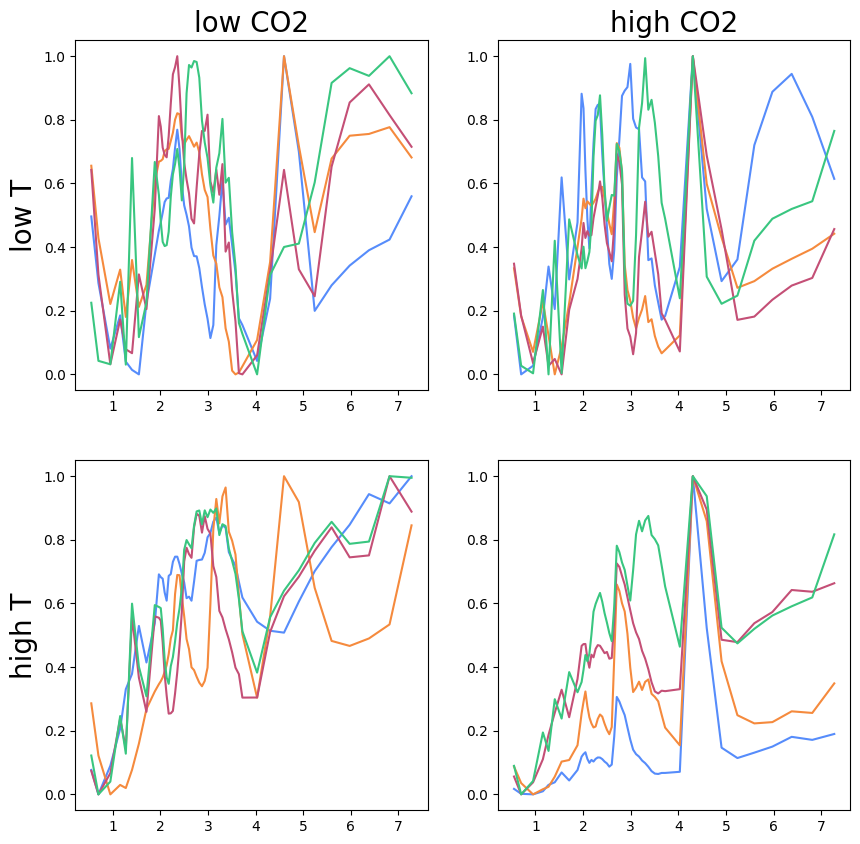

In [114]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax[0,0].plot(wavelengths, X_norm[lowT_lowCO2_ind].T)
ax[0,1].plot(wavelengths, X_norm[lowT_highCO2_ind].T)
ax[1,0].plot(wavelengths, X_norm[highT_lowCO2_ind].T)
ax[1,1].plot(wavelengths, X_norm[highT_highCO2_ind].T)

ax[0,0].set_title('low CO2', fontsize=20)
ax[0,1].set_title('high CO2', fontsize=20)
ax[0,0].set_ylabel('low T', fontsize=20)
ax[1,0].set_ylabel('high T', fontsize=20)